In [ ]:
! pip install mysql-connector-python

In [ ]:
import mysql.connector
import pandas as pd

# Connect to server
conn = mysql.connector.connect(
    # Address of server
    host="localhost",
    port=3306,
    # Username to use
    user="root",
    # Password for username
    password="CAP4770spring25")

# Get a cursor
cur = conn.cursor()

# Select database
cur.execute("USE cap4770")

# Load into datafram from database
vehicleEfficiencyFromMYSQL = pd.read_sql_query("select * from vehicle_fuel_economy", con=conn)

# Close connection
conn.close

vehicleEfficiencyFromMYSQL

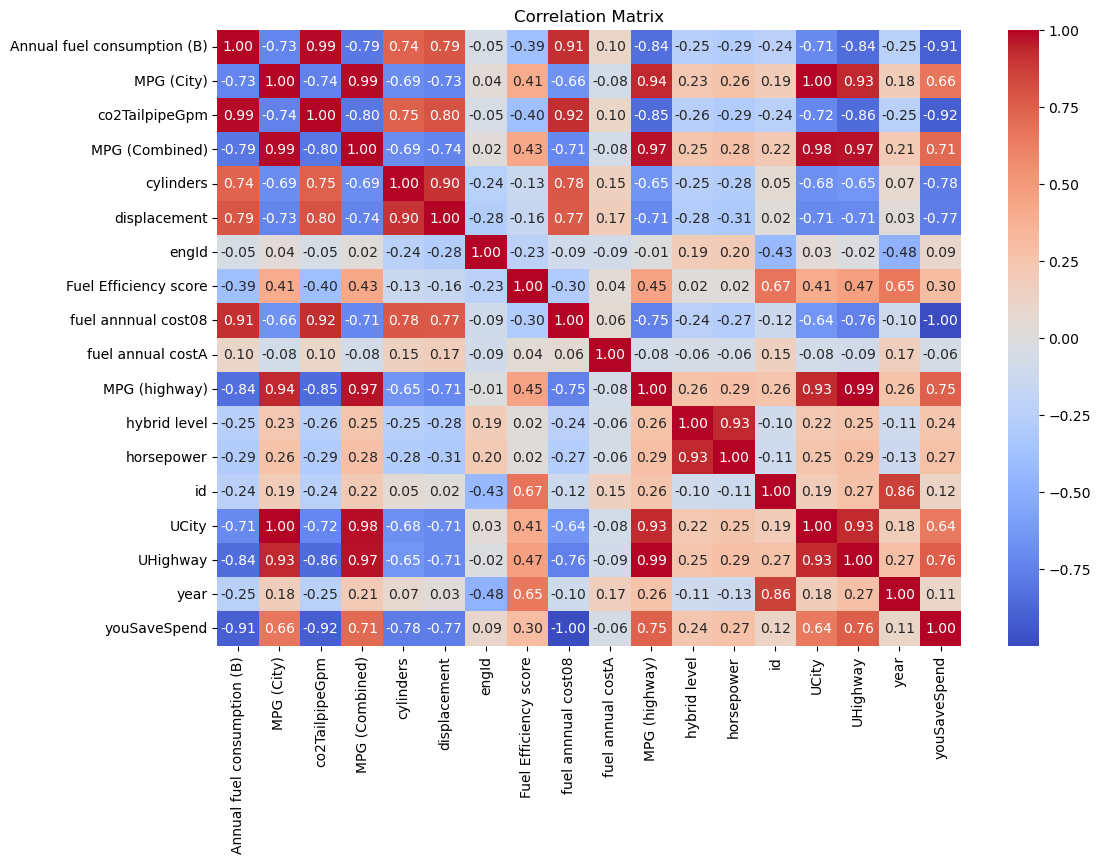

Selected Features using RFE:  ['Annual fuel consumption (B)', 'MPG (City)', 'displacement', 'Fuel Efficiency score', 'MPG (highway)']
Mean Squared Error: 0.13107152494917854
Mean Absolute Error: 0.30063705815338687
R^2 Score: 0.9951058302735623


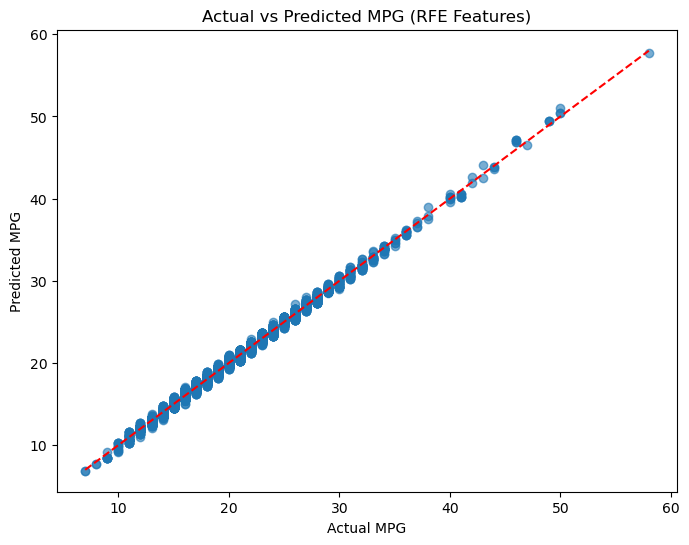

Average MSE: 0.15383312347016037
Average MAE: 0.3211004561641563
R^2 Scores: [0.99363419 0.99042871 0.98594975 0.98279055 0.96592424]
Average R^2: 0.9837454874309863

Lasso Regression model
Selected Features using Lasso:
youSaveSpend      0.000335
co2TailpipeGpm   -0.030082
dtype: float64
Lasso Model Evaluation:
Mean Squared Error: 4.038975931315333
Mean Absolute Error: 1.2782335919994676
R^2 Score: 0.8491859026091376


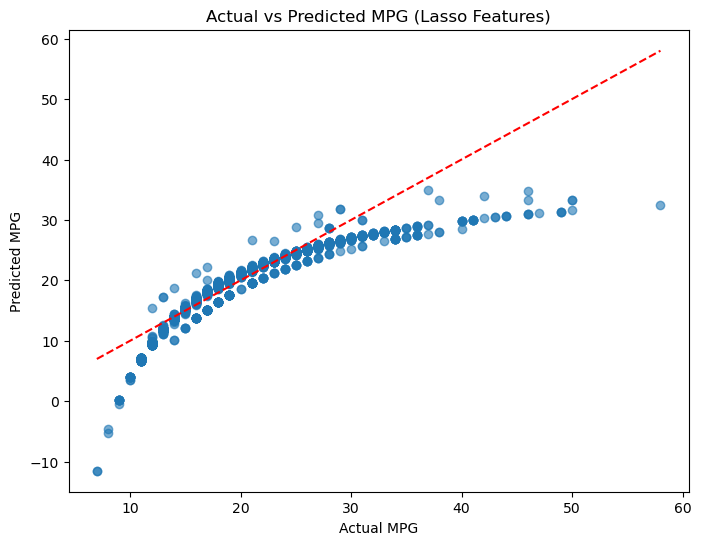

Average MSE: 8.130810025085255
Average MAE: 1.822799879093975
R^2 Scores: [ 0.40556515  0.82526126  0.73912486  0.78189141 -1.95563034]
Average R^2: 0.15924246799696568


In [17]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings('ignore')

vehicleEfficiency = pd.read_csv('vehicle-fuel-economy.csv')

#Data visualization and preprocessing
vehicleEfficiency.info()
vehicleEfficiency.describe()

%matplotlib inline
sns.pairplot(vehicleEfficiency, diag_kind='kde');
plt.show()

cor = vehicleEfficiency.select_dtypes(include=[np.number]).corr()
print(cor)

plt.figure(figsize=(12, 8))
sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

vehicleEfficiency = vehicleEfficiency.dropna()
X = vehicleEfficiency.drop(['UCity','UHighway','fuel annual costA', 'id', 'engId', 'year', 'cylinders', 'engine description', 'fuelType', 'fuelType1', 'make', 'model', 'transmission', 'VClass', 'createdOn', 'modifiedOn', 'MPG (Combined)'  ], axis=1)
y = vehicleEfficiency['MPG (Combined)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#RFE Model 
model = LinearRegression()

rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_train, y_train)

rfe_selected_features = X.columns[rfe.support_]
print("Selected Features using RFE: ", selected_features.tolist())

X_train_rfe = X_train[selected_features]
X_test_rfe = X_test[selected_features]

model.fit(X_train_selected, y_train)

y_pred_rfe = model.predict(X_test_selected)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R^2 Score:", r2)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rfe, alpha=0.6)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG (RFE Features)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#Cross Validation
X_selected = X[selected_features]
scoring = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']
results = cross_validate(model, X_selected, y, cv=5, scoring=scoring, return_train_score=False)

print("Average MSE:", -np.mean(results['test_neg_mean_squared_error']))
print("Average MAE:", -np.mean(results['test_neg_mean_absolute_error']))
print("R^2 Scores:", results['test_r2'])
print("Average R^2:", np.mean(results['test_r2']))

# Lasso model 

print("\n" + "Lasso Regression model")
lasso = LassoCV(cv=5).fit(X_train, y_train)

coef = pd.Series(lasso.coef_, index=X.columns)

selected_by_lasso = coef[coef != 0]
print("Selected Features using Lasso:")
print(selected_by_lasso.sort_values(ascending=False))

X_train_lasso = X_train[selected_by_lasso.index.tolist()]
X_test_lasso = X_test[selected_by_lasso.index.tolist()]

model_lasso = LinearRegression()
model_lasso.fit(X_train_lasso, y_train)

y_pred_lasso = model_lasso.predict(X_test_lasso)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Model Evaluation:")
print("Mean Squared Error:", mse_lasso)
print("Mean Absolute Error:", mae_lasso)
print("R^2 Score:", r2_lasso)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lasso, alpha=0.6)
plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs Predicted MPG (Lasso Features)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

#Cross Validation
X_selected_lasso = X[selected_by_lasso.index.tolist()]
scoring = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']
results = cross_validate(model, X_selected_lasso, y, cv=5, scoring=scoring, return_train_score=False)

print("Average MSE:", -np.mean(results['test_neg_mean_squared_error']))
print("Average MAE:", -np.mean(results['test_neg_mean_absolute_error']))
print("R^2 Scores:", results['test_r2'])
print("Average R^2:", np.mean(results['test_r2']))